In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [12]:
data = pd.read_json("results/run_report_1.json")
data = data[data["prompt_length"] == 999]
data

,time,device_count,prompt_length,program,max_seq_len,max_tokens
4,3.884556,1,999,experimental,4096,10
5,3.764298,1,999,voltage,4096,10
6,3.919331,1,999,experimental,4096,10
7,3.506612,1,999,voltage,4096,10
8,4.093272,1,999,experimental,4096,10
...,...,...,...,...,...,...
799,4.368335,8,999,voltage,4096,10
800,4.164231,8,999,experimental,4096,10
801,3.945214,8,999,voltage,4096,10
802,4.001942,8,999,experimental,4096,10


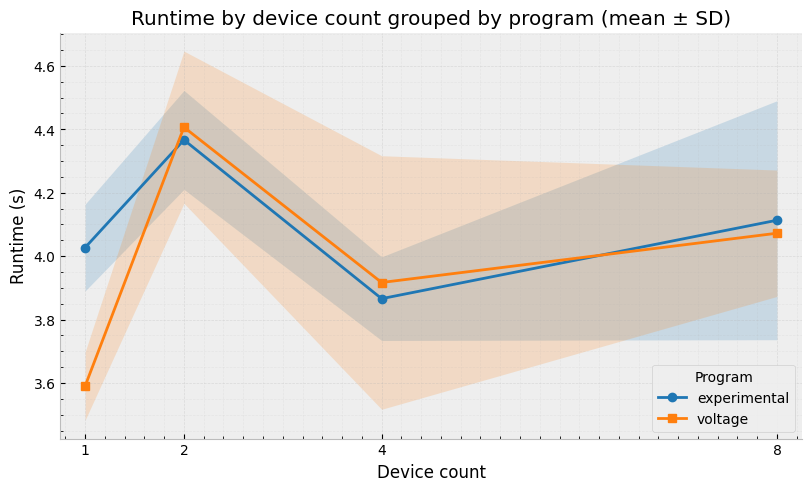

In [13]:
# Aggregate mean and standard deviation of runtime by program and device count
stats = (
    data.groupby(["program", "device_count"], as_index=False)["time"]
        .agg(mean="mean", std="std")
)
stats["std"] = stats["std"].fillna(0.0)

# Polished plot: lines with markers + shaded ±SD bands, nicer style and legend
plt.style.use("bmh")
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

cmap = plt.get_cmap("tab10")
markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", ">"]
xticks = sorted(stats["device_count"].unique())

for i, (prog, grp) in enumerate(stats.groupby("program", sort=False)):
    grp = grp.sort_values("device_count")
    color = cmap(i % 10)
    ax.plot(
        grp["device_count"], grp["mean"],
        color=color, marker=markers[i % len(markers)],
        linewidth=2, markersize=6, label=prog,
    )
    ax.fill_between(
        grp["device_count"],
        grp["mean"] - grp["std"],
        grp["mean"] + grp["std"],
        color=color, alpha=0.18, linewidth=0,
    )

ax.set_xticks(xticks)
ax.set_xlim(min(xticks) - 0.25, max(xticks) + 0.25)
ax.set_xlabel("Device count")
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime by device count grouped by program (mean ± SD)")

ax.grid(which="major", alpha=0.35)
ax.minorticks_on()
ax.grid(which="minor", alpha=0.15, linestyle="--")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(title="Program", frameon=True, fancybox=True, framealpha=0.9)
plt.show()

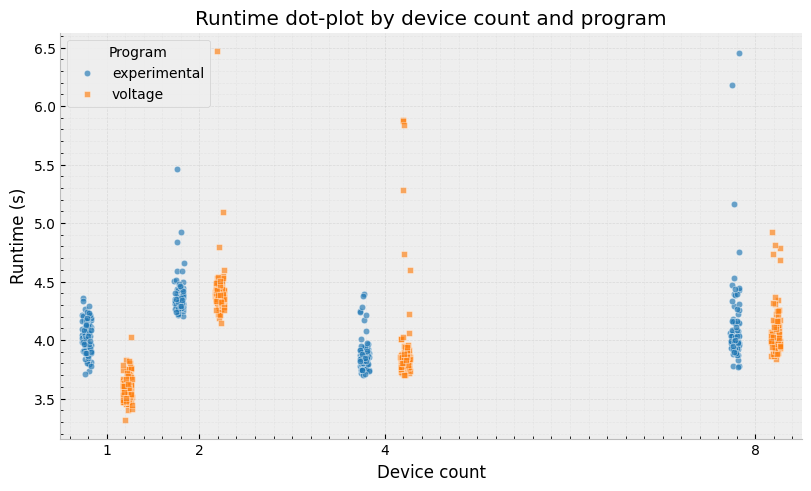

In [14]:

# Dot-plot of individual runs: time vs. device_count, colored by program with slight jitter
progs = list(stats["program"].unique())
offsets = np.linspace(-0.22, 0.22, num=len(progs))
jitter = 0.05

fig2, ax2 = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

for idx, prog in enumerate(progs):
    d = data[data["program"] == prog]
    rng = np.random.default_rng(100 + idx)
    x = d["device_count"].to_numpy(dtype=float) + offsets[idx] + rng.uniform(-jitter, jitter, size=len(d))
    ax2.scatter(
        x, d["time"],
        s=22, alpha=0.65,
        color=cmap(idx % 10),
        marker=markers[idx % len(markers)],
        edgecolor="white", linewidth=0.4,
        label=prog,
    )

ax2.set_xticks(xticks)
ax2.set_xlim(min(xticks) - 0.5, max(xticks) + 0.5)
ax2.set_xlabel("Device count")
ax2.set_ylabel("Runtime (s)")
ax2.set_title("Runtime dot-plot by device count and program")

ax2.grid(which="major", alpha=0.35)
ax2.minorticks_on()
ax2.grid(which="minor", alpha=0.15, linestyle="--")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

ax2.legend(title="Program", frameon=True, fancybox=True, framealpha=0.9)
plt.show()

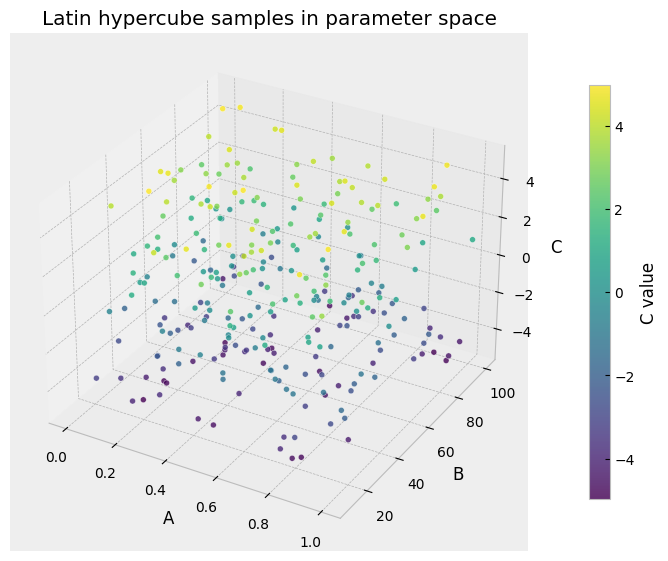

In [16]:
import numpy as np
from scipy.stats import qmc
import matplotlib.pyplot as plt

# 1) parameter ranges: [low, high] per variable
bounds = np.array([
    [0.0, 1.0],     # param A
    [10.0, 100.0],  # param B
    [-5.0, 5.0],    # param C
])
d = bounds.shape[0]
N = 300  # try 10–20×d and scale up as needed

# 2) Latin hypercube sample in [0,1]^d, then scale to bounds
sampler = qmc.LatinHypercube(d)
X01 = sampler.random(N)
X = qmc.scale(X01, bounds[:,0], bounds[:,1])  # shape (N, d)

# 3) visualize the sampled points in 3D (A, B, C)
fig3d = plt.figure(figsize=(7.5, 5.5), constrained_layout=True)
ax3d = fig3d.add_subplot(111, projection="3d")

sc = ax3d.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=X[:, 2], cmap="viridis",
    s=18, alpha=0.8, edgecolor="white", linewidth=0.3,
)

ax3d.set_xlabel("A")
ax3d.set_ylabel("B")
ax3d.set_zlabel("C")
ax3d.set_title("Latin hypercube samples in parameter space")
cb = plt.colorbar(sc, ax=ax3d, pad=0.1, shrink=0.8)
cb.set_label("C value")

plt.show()


In [17]:
from scipy.stats import qmc

# LHS over 1 dimension, reproducible
sampler = qmc.LatinHypercube(d=1, seed=42)

# draw n integers in [0, 100] inclusive
n = 12
xs = sampler.integers(l_bounds=[0], u_bounds=[100], n=n, endpoint=True).ravel()
print(xs)

[86  4 43 36 74 75 60 18 32 97 13 51]
